#  __1- Dataset Preparation__ 

## 1.1 Resizing DataSet to Speed Up the Training

 <span style="color: red;"> DO NOT RUN THIS CELL!!!!</span>

In [ ]:
"""
-----------------------------------------------------------------------------
This section takes the original, large images from the dataset and shrinks 
them down to 224x224 pixels. It looks through each chosen folder, opens the images, 
resizes them using a high-quality tool called LANCZOS, and saves them in a 
new folder. It makes sure to keep the exact same folder structure as the original.

Outcome: All images are standardized to a smaller size. This drastically saves 
computer memory and speeds up the AI training process without losing the important 
details of the hand gestures.
-----------------------------------------------------------------------------
"""
import os # deal with files and folders
from PIL import Image # open images and edit it

original_path = r"D:\Downloadf\second_dataset"
resized_path = r"D:\Downloadf\gestures_resized" # new folder to save resized images 

target_size = (224, 224) # sutiable with ResNet

for root, dirs, files in os.walk(original_path): # for loop to go inside the path, foldes and files
    
    for file in files: # to make sure that we are dealing with images only
        if file.endswith(('.png', '.jpg', '.jpeg')):
            
             original_img_path = os.path.join(root, file) # build a path for new image (يسوي مسار للصورة الجديدة اللي صغرناها)
            
             # إنشاء نفس الهيكل داخل مجلد جديد - to creat a new folder with the same structure
             relative_path = os.path.relpath(root, original_path)
             new_folder = os.path.join(resized_path, relative_path)
             os.makedirs(new_folder, exist_ok=True)
            
             new_img_path = os.path.join(new_folder, file)
            
             # فتح الصورة وتصغيرها - open image and resize it
             img = Image.open(original_img_path)
             img = img.resize(target_size, Image.LANCZOS) # LANCZOS most popular algorithm to resize images
            
             # حفظ بجودة عالية - save image with high quality
             img.save(new_img_path, quality=90)
            

original_size = os.path.getsize(original_img_path) / 1024
new_size = os.path.getsize(new_img_path) / 1024

print(f"Original size: {original_size:.2f} KB")
print(f"Resized size: {new_size:.2f} KB")


## 1.2 Explore Dataset and Choose Gestures

In [ ]:
"""
-----------------------------------------------------------------------------
This section filters the dataset to keep only the hand gestures we actually need 
for our rehabilitation game: "Palm" and "Fist". It scans the new resized folder, 
links the correct original folders to our two labels, and saves the exact file 
locations into a clean data table (called a DataFrame) so the program can read 
them easily later.

Outcome: Unneeded hand gestures are removed. We now have a clean, balanced list 
showing exactly where the Palm and Fist images are saved on the computer.
-----------------------------------------------------------------------------
"""
import os
import pandas as pd

dataset_path = r"C:\Users\totom\Downloads\gestures_resized" #new dataset

relevant_gestures = { #choosen gustures
    "01_palm": "Palm",
    "08_palm_moved": "Palm",
    "10_down": "Palm",
    "03_fist": "Fist",
    "04_fist_moved": "Fist",
    "02_closeup_fist": "Fist"
}

data = []

for subject in os.listdir(dataset_path): # walk through everything in the folder
    subject_path = os.path.join(dataset_path, subject)

    if os.path.isdir(subject_path): # check if it's foldr\dir

        for gesture_folder in os.listdir(subject_path): # walk through each gesture

            if gesture_folder in relevant_gestures: # chech if it's desired gesture
                gesture_path = os.path.join(subject_path, gesture_folder)

                # يدخل داخل كل الملفات حتى لو في مجلد right - os.walk function: to solve right hand images problem
                for root, dirs, files in os.walk(gesture_path):
                    for file in files:
                        if file.endswith(('.png', '.jpg', '.jpeg')):
                            img_path = os.path.join(root, file)

                            data.append({ # same image path and classification
                                "image_path": img_path,
                                "label": relevant_gestures[gesture_folder]
                            })

df = pd.DataFrame(data) #df means DATA FRAME help to store data in table like exel
print(df.head()) # to print first 5 raws
print("Total number for each gesture:")
print(df["label"].value_counts()) # count how many image in each label


                                          image_path label
0  C:\Users\totom\Downloads\gestures_resized\gest...  Palm
1  C:\Users\totom\Downloads\gestures_resized\gest...  Palm
2  C:\Users\totom\Downloads\gestures_resized\gest...  Palm
3  C:\Users\totom\Downloads\gestures_resized\gest...  Palm
4  C:\Users\totom\Downloads\gestures_resized\gest...  Palm
Total number for each gesture:
label
Palm    4678
Fist    4651
Name: count, dtype: int64


## 1.3 Visualize Dataset

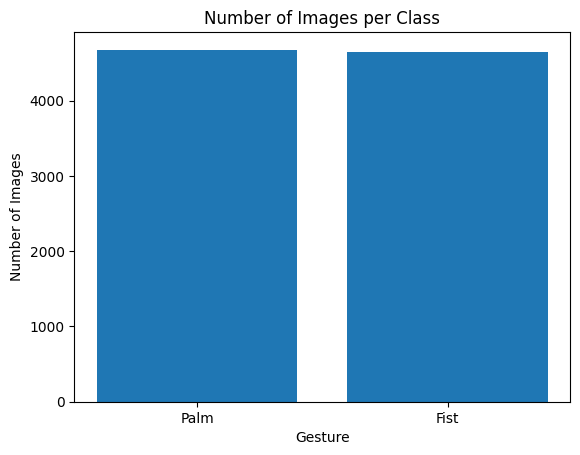

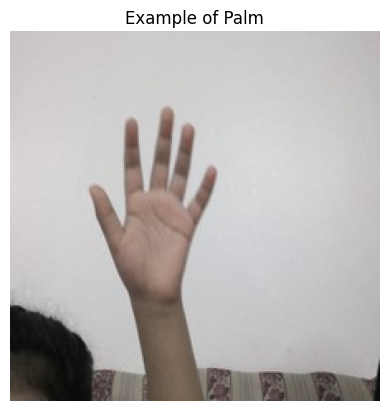

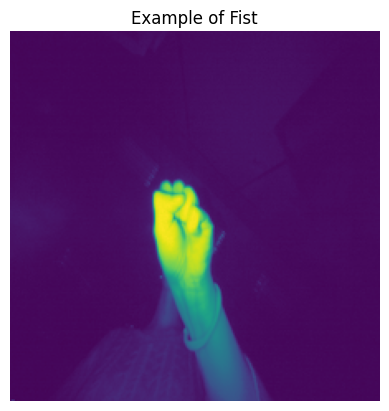

In [ ]:
"""
-----------------------------------------------------------------------------
This section creates a bar chart to show the total number of Palm images compared 
to Fist images. This is done to prove that the numbers are equal and balanced. 
It also picks one random image from each group and displays it on the screen to 
make sure the images are clear and matched with the correct label.

Outcome: We get visual proof that our data is balanced (not biased toward one gesture) 
and that the image files are correct and ready to be used.
-----------------------------------------------------------------------------
"""
import matplotlib.pyplot as plt
from PIL import Image
import random

class_counts = df["label"].value_counts() 

plt.figure()
plt.bar(class_counts.index, class_counts.values) # chart to show the num of images in each class
plt.xlabel("Gesture")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")
plt.show()

for label in df["label"].unique(): # show sample from each class
    
    sample_path = random.choice(df[df["label"] == label]["image_path"].values) #choose random image
    
    img = Image.open(sample_path)
    
    plt.figure() # dispaly imge
    plt.imshow(img)
    plt.title(f"Example of {label}")
    plt.axis("off")
    plt.show()


## 1.4 Data Split (70% training - 30% validation & testing)

In [ ]:
"""
-----------------------------------------------------------------------------
This section divides all the images into three separate groups. 70% of the images 
are used to teach the AI, 15% are used to check its progress during training, and 
15% are kept completely hidden for a final test. It uses a tool called `stratify` 
to ensure the 50/50 ratio of Palm and Fist images stays perfectly balanced in all 
three groups. Finally, it saves these lists into CSV files.

Outcome: The data is safely divided into training and testing lists and saved as 
CSV files (`train.csv`, `val.csv`, `test.csv`). The AI is now fully ready to be 
trained scientifically.
-----------------------------------------------------------------------------
"""
from sklearn.model_selection import train_test_split

# first split: Train (70%) , Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# second split: Validation (15%) ,Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)
# to use this prameter in Model notebook
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))
print("\nTrain distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())


Train size: 6530
Validation size: 1399
Test size: 1400

Train distribution:
label
Palm    3274
Fist    3256
Name: count, dtype: int64

Validation distribution:
label
Palm    702
Fist    697
Name: count, dtype: int64

Test distribution:
label
Palm    702
Fist    698
Name: count, dtype: int64
